# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'


In [2]:
# Reproject region to geographic CRS
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling


def reproject_to_meters_optimized(src_path, dst_path, target_crs=None):
    """Reproject the GeoTIFF to a CRS with meters, matching the original resolution and applying compression."""
    with rasterio.open(src_path) as src:
        # Set target CRS (default: UTM based on the image center)
        if target_crs is None:
            centroid = ((src.bounds.left + src.bounds.right) / 2, 
                        (src.bounds.top + src.bounds.bottom) / 2)
            utm_zone = int((centroid[0] + 180) // 6) + 1
            is_northern = centroid[1] >= 0
            target_crs = f"EPSG:{32600 + utm_zone if is_northern else 32700 + utm_zone}"
        
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        
        # Match resolution to the original
        dst_resolution = (src.res[0], src.res[1])
        width = int((src.bounds.right - src.bounds.left) / dst_resolution[0])
        height = int((src.bounds.top - src.bounds.bottom) / dst_resolution[1])
        
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height,
            'compress': 'lzw'  # Add compression
        })
        
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.nearest  # Use nearest neighbor for speed
                )
    return dst_path


## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [3]:
simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5

max_iterations = 20

Reached maximum iterations without full convergence.


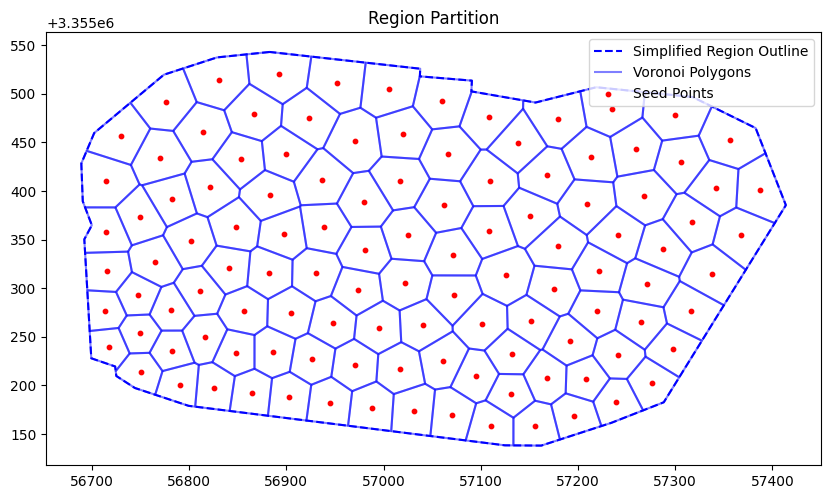

In [4]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=32614)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
voronoi_gdf, points_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
voronoi_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Polygons")
points_gdf.plot(ax=ax, color="red", markersize=10, label="Seed Points")
plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach.

Here we might plan a first pass at how we approach the full job. 

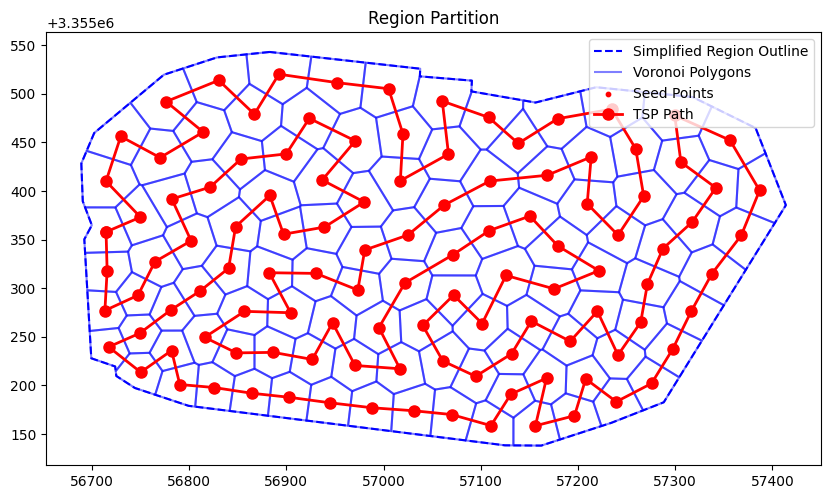

In [5]:
from plant_search.pathfinding import (
    compute_tsp_path,
    calculate_optimal_route,
    calculate_total_distance,
    plot_tsp_path_on_image,
)
import matplotlib.pyplot as plt



# points_gdf
plot_centroids = points_gdf.geometry
plot_coords_list = [(point.x, point.y) for point in plot_centroids]
# path = compute_tsp_path(plot_coords_list)
path = calculate_optimal_route(plot_coords_list)

fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
voronoi_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Polygons")
points_gdf.plot(ax=ax, color="red", markersize=10, label="Seed Points")

# Overlay the TSP path
ordered_centroids = [plot_coords_list[i] for i in path]
x, y = zip(*ordered_centroids)
plt.plot(x, y, 'o-', color='red', label='TSP Path', markersize=8, linewidth=2)

plt.legend()
plt.title("Region Partition")
plt.show()


## Micro Planning

Perform image analysis on each smaller section of our greater region.

In [6]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

# Path to the original image
# raster_path = "path_to_your_image.tif"

# Example: Select a Voronoi polygon by an attribute or ID
selected_partition = voronoi_gdf[voronoi_gdf['id'] == 0]


# Convert the selected polygon to GeoJSON-like format
# geometry = [mapping(selected_partition.geometry.iloc[0])]

# # Open the raster and clip it
# with rasterio.open(file_path) as src:
#     out_image, out_transform = mask(src, geometry, crop=True)
#     out_meta = src.meta.copy()

# # Update metadata for the clipped section
# out_meta.update({
#     "driver": "GTiff",
#     "height": out_image.shape[1],
#     "width": out_image.shape[2],
#     "transform": out_transform
# })
